In [21]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib

import mne


raw_file = r"D:\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=False)

Extracting parameters from D:\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr...
Setting channel info structure...


c:\Users\CSNDLab\.conda\envs\EEG_analysis\Lib\site-packages\mne\viz\utils.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


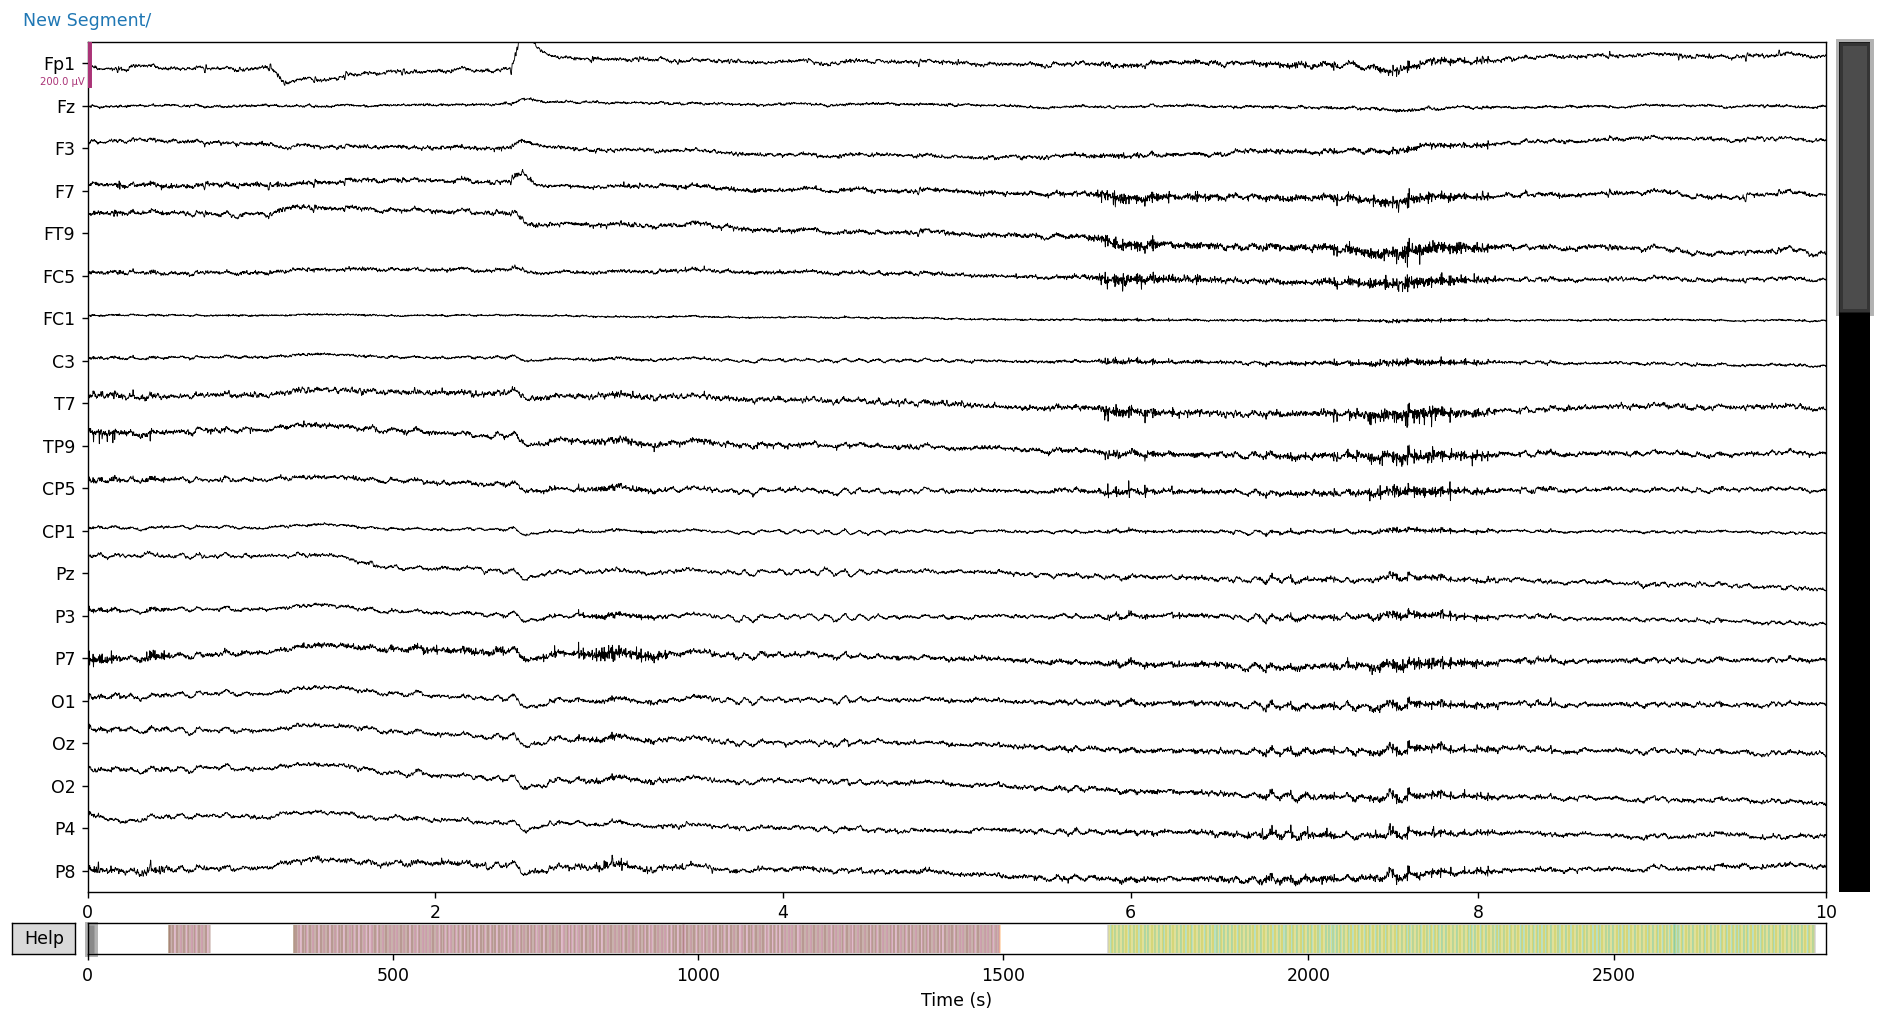

Channels marked as bad:
none


In [22]:
 # it is useful to scroll eeg data 
%matplotlib qt
raw.plot(scalings=dict(eeg=1e-4),clipping='transparent')

In [3]:
#import the channel loaction 
"""builtin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in builtin_montages:
    print(f"{montage_name}: {montage_description}") """
raw.set_montage("easycap-M1")

Measurement date,"June 02, 2024 13:12:19 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,66 points
Good channels,63 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,1000.00 Hz
Highpass,0.00 Hz
Lowpass,280.00 Hz


Approximating Fpz location by mirroring Oz along the X and Y axes.


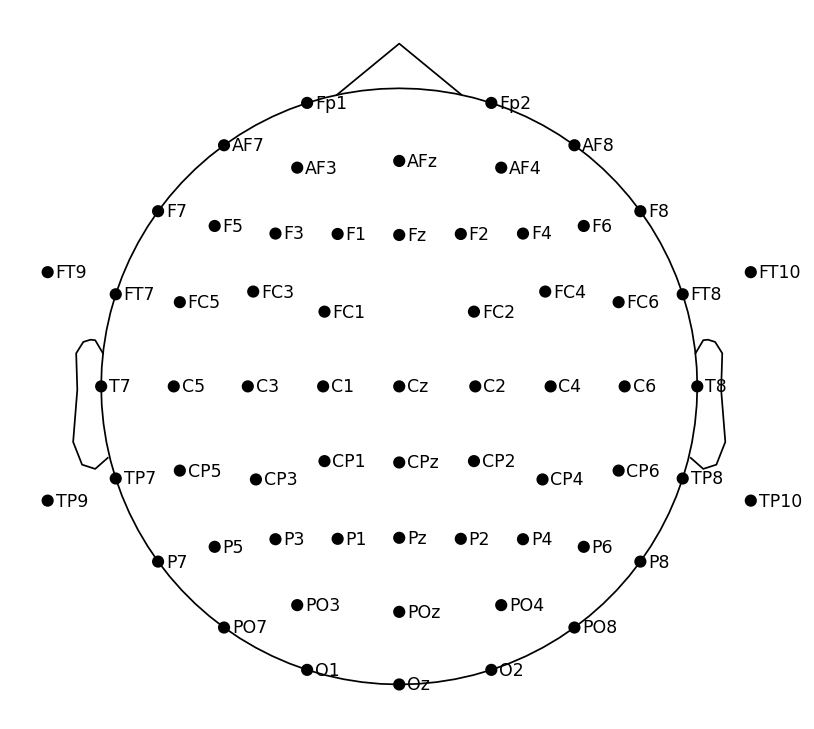

In [4]:

raw.plot_sensors(show_names=True, sphere="eeglab")

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


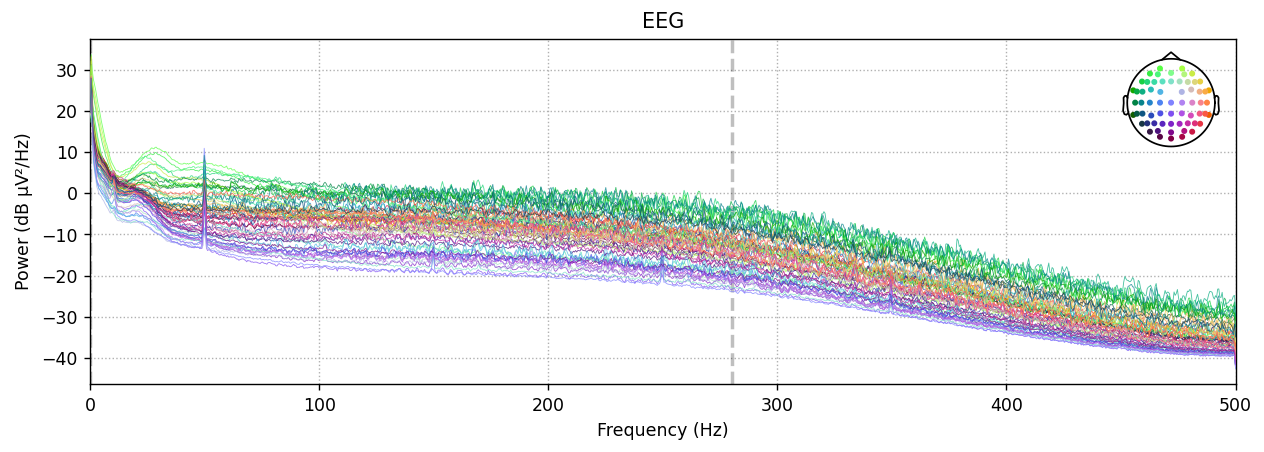

In [5]:
raw.compute_psd().plot(picks="data", amplitude=False)

In [11]:
raw.resample(sfreq=250)
raw.info

Measurement date,"May 27, 2024 16:46:01 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,Not available
Good channels,63 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.00 Hz
Lowpass,125.00 Hz


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_11372\3167296901.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot(picks="data", amplitude=False)


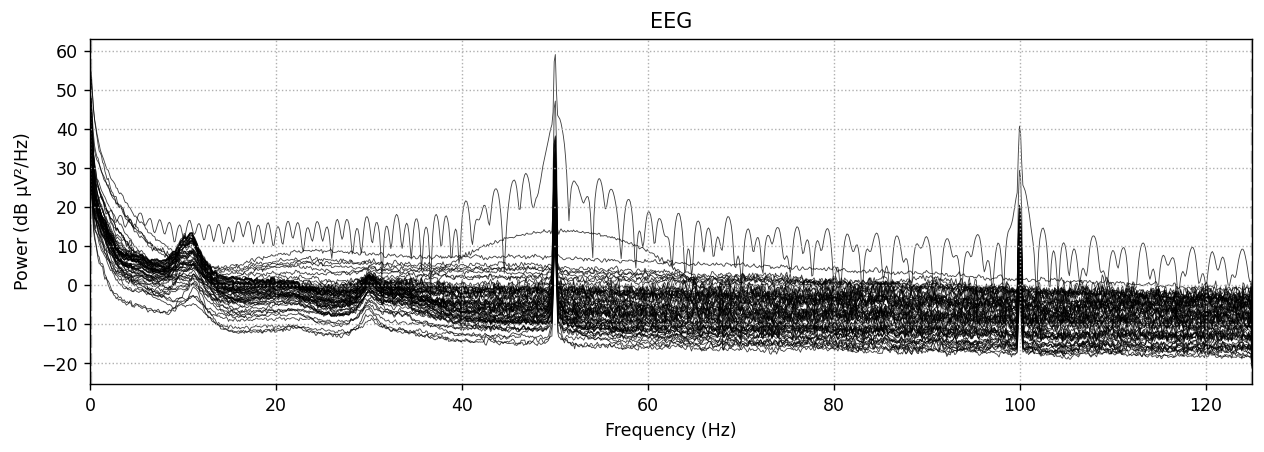

In [12]:
raw.compute_psd().plot(picks="data", amplitude=False)

### Filtering 

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_11372\357293733.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot(picks="data", amplitude=False)


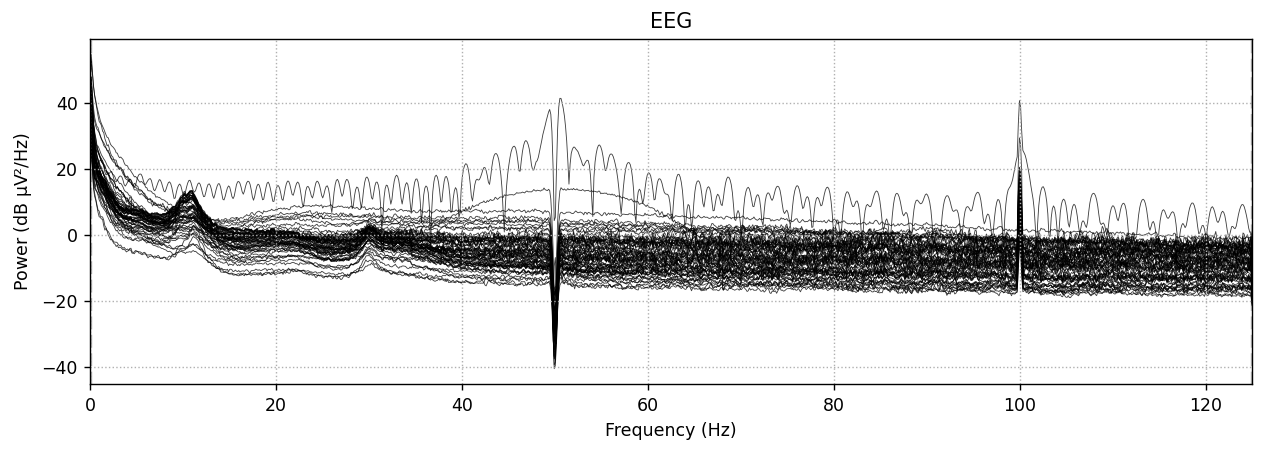

In [13]:
raw.notch_filter(50)
raw.compute_psd().plot(picks="data", amplitude=False)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_11372\2259284744.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot(picks="data", amplitude=False)


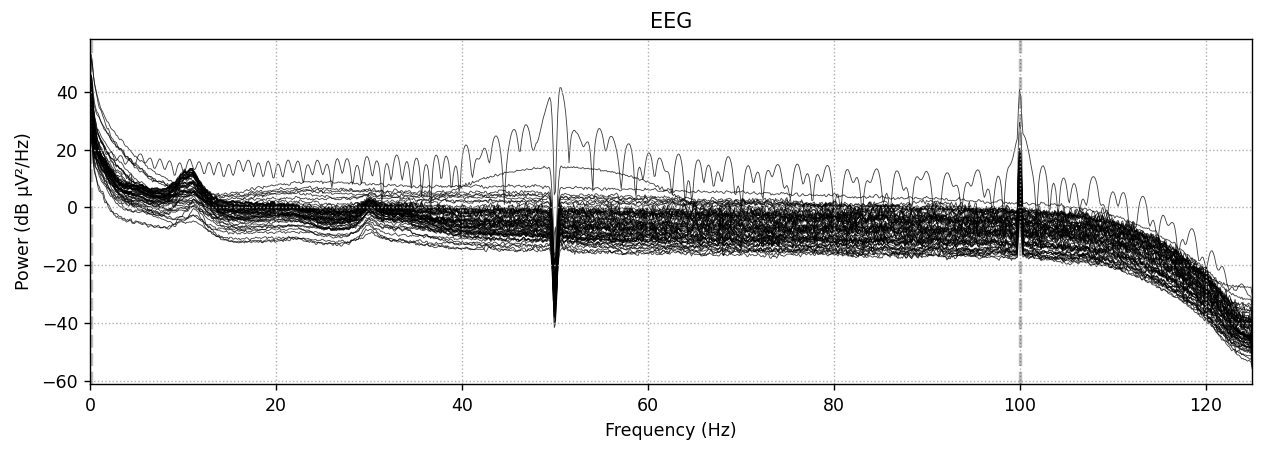

In [14]:
raw.filter(l_freq=0.1,h_freq=100)
raw.compute_psd().plot(picks="data", amplitude=False)

### Epoching 

In [15]:
#Get the events and its marker
events,event_dict = mne.events_from_annotations(raw)
print(event_dict)

Used Annotations descriptions: ['New Segment/', 'Response/R  1', 'Stimulus/S  5', 'Stimulus/S  8', 'Stimulus/S  9', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15']
{'New Segment/': 99999, 'Response/R  1': 1001, 'Stimulus/S  5': 5, 'Stimulus/S  8': 8, 'Stimulus/S  9': 9, 'Stimulus/S 11': 11, 'Stimulus/S 12': 12, 'Stimulus/S 13': 13, 'Stimulus/S 14': 14, 'Stimulus/S 15': 15}


In [16]:
epochs = mne.Epochs(raw, events, event_id=[14,15,24,25], tmin=-0.3, tmax=0.7, preload=True)
#fig = epochs.plot(events=events)

ValueError: No matching events found for 24 (event id 24)

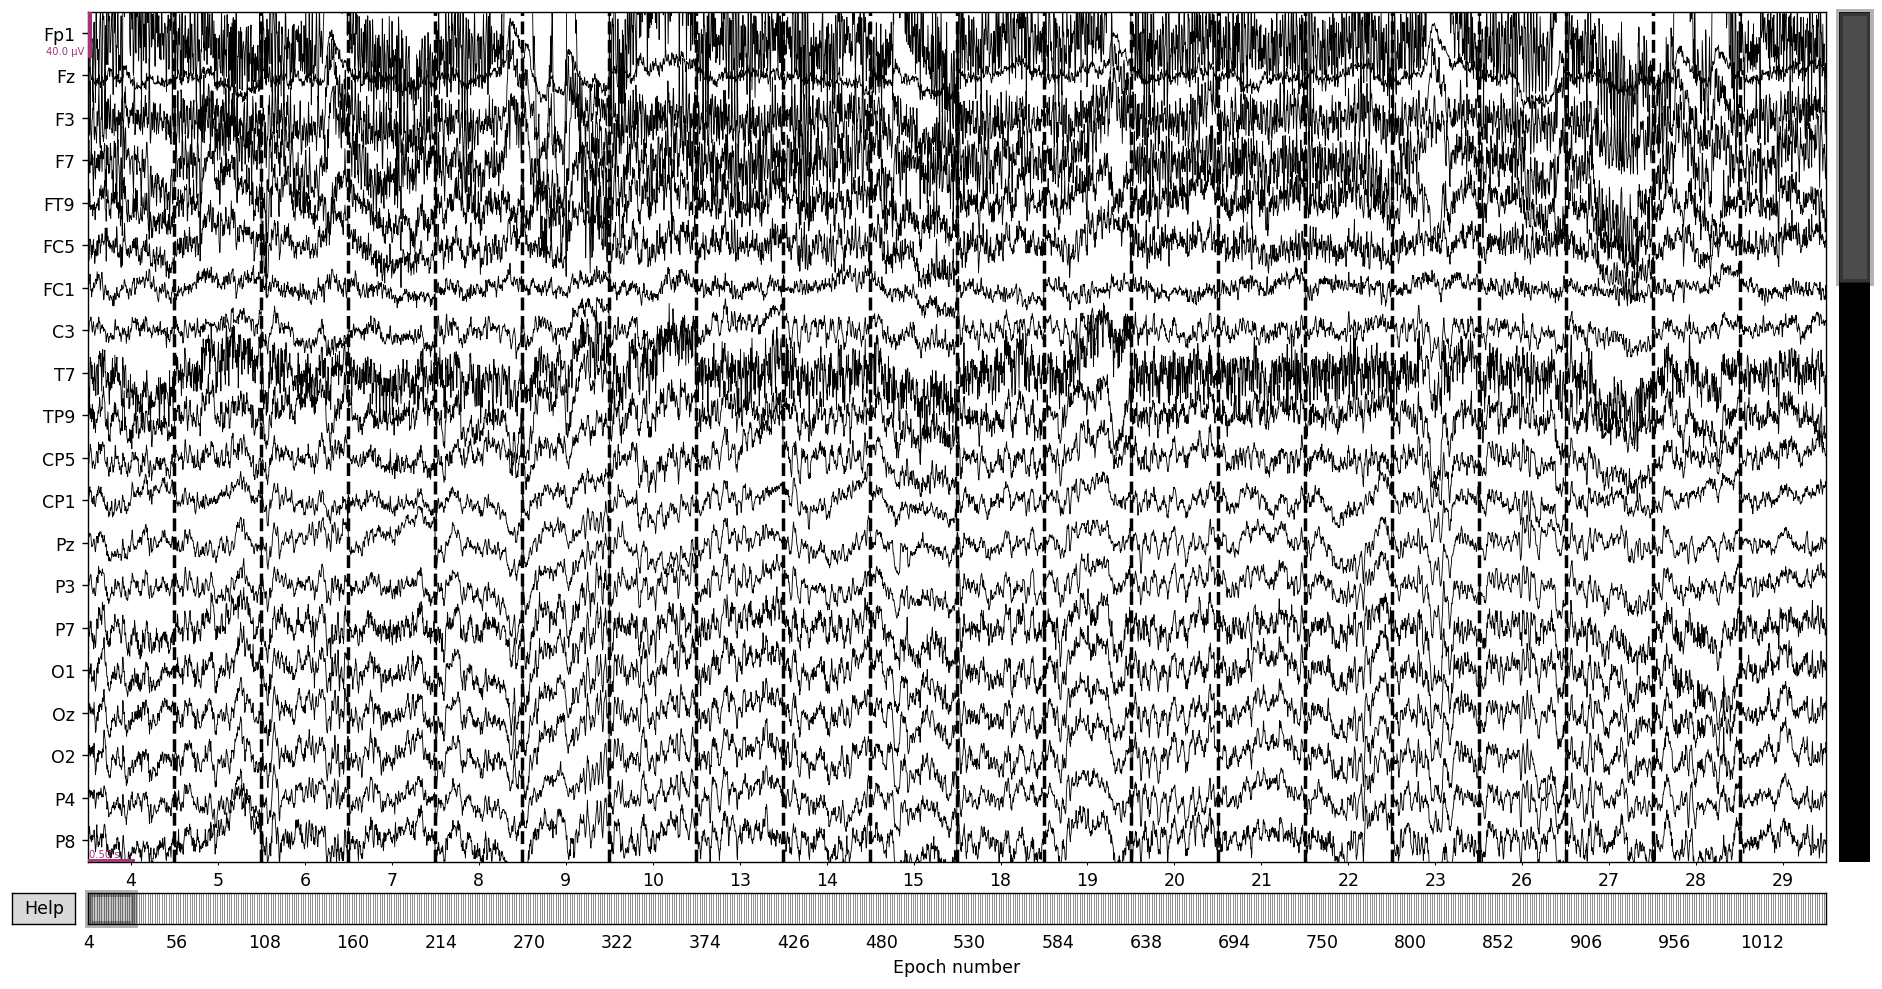

In [ ]:
epochs['14'].plot()

In [23]:
print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))

Total Numner of event in Block 1 : 750 150
Total Numner of event in Block 2 : 750 150


### remove eeg epochs with thresold 

In [14]:

# Define the rejection criteria
"""reject_criteria = dict(eeg=70e-6)  # 70 microvolts
reject_criteria  = dict(
    eeg=lambda x: (
        (np.percentile(np.abs(x), 99, axis=1) > 70e-6  ).any(),
        "signal > 70 microV somewhere",
    )
)

# Drop bad epochs based on the rejection criteria
epochs.drop_bad(reject=reject_criteria)"""

1243 bad epochs dropped


Number of events,557
Events,14: 24715: 5624: 21725: 37
Time range,-0.300 – 0.700 s
Baseline,-0.300 – 0.000 s


In [24]:
# Define the rejection criteria
reject_criteria = dict(eeg=70e-6)  # 70 microvolts

# Custom rejection logic
bad_epochs = []
for i, epoch in enumerate(epochs):
    # Find channels that exceed the threshold
    #print((abs(epoch) > reject_criteria['eeg']).any(axis=1).sum())
    bad_channels = (abs(epoch) > reject_criteria['eeg']).any(axis=1) 

    # Check if more than 3 electrodes exceed the threshold
   
    if bad_channels.sum() > 5:
        bad_epochs.append(i)

# Drop the bad epochs
epochs.drop(bad_epochs)


Dropped 797 epochs: 0, 1, 2, 4, 5, 6, 10, 13, 17, 19, 20, 21, 25, 27, 31, 35, 36, 38, 39, 40, 41, 43, 50, 51, 55, 57, 58, 59, 62, 65, 66, 67, 68, 69, 70, 71, 72, 75, 76, 77, 81, 83, 86, 87, 89, 94, 98, 103, 104, 107, 109, 111, 112, 115, 122, 127, 135, 137, 139, 140, 141, 142, 145, 149, 153, 156, 157, 163, 165, 166, 167, 168, 171, 172, 175, 176, 178, 179, 181, 183, 189, 191, 193, 195, 196, 199, 201, 203, 207, 208, 216, 218, 222, 223, 224, 228, 229, 235, 237, 238, 239, 242, 243, 247, 249, 251, 252, 254, 256, 257, 259, 261, 262, 263, 264, 265, 268, 270, 274, 276, 280, 282, 283, 284, 285, 287, 288, 289, 291, 297, 298, 300, 303, 305, 306, 307, 309, 310, 312, 314, 316, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 332, 335, 337, 340, 341, 342, 343, 350, 352, 358, 359, 360, 361, 362, 363, 364, 365, 366, 368, 369, 370, 371, 373, 374, 375, 376, 377, 378, 379, 380, 381, 383, 385, 386, 387, 388, 395, 398, 402, 408, 410, 412, 413, 416, 417, 420, 421, 424, 425, 426, 427, 428, 429, 431, 432, 435

Number of events,1003
Events,14: 41115: 9024: 43225: 70
Time range,-0.300 – 0.700 s
Baseline,-0.300 – 0.000 s


In [25]:
print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))

Total Numner of event in Block 1 : 411 90
Total Numner of event in Block 2 : 432 70


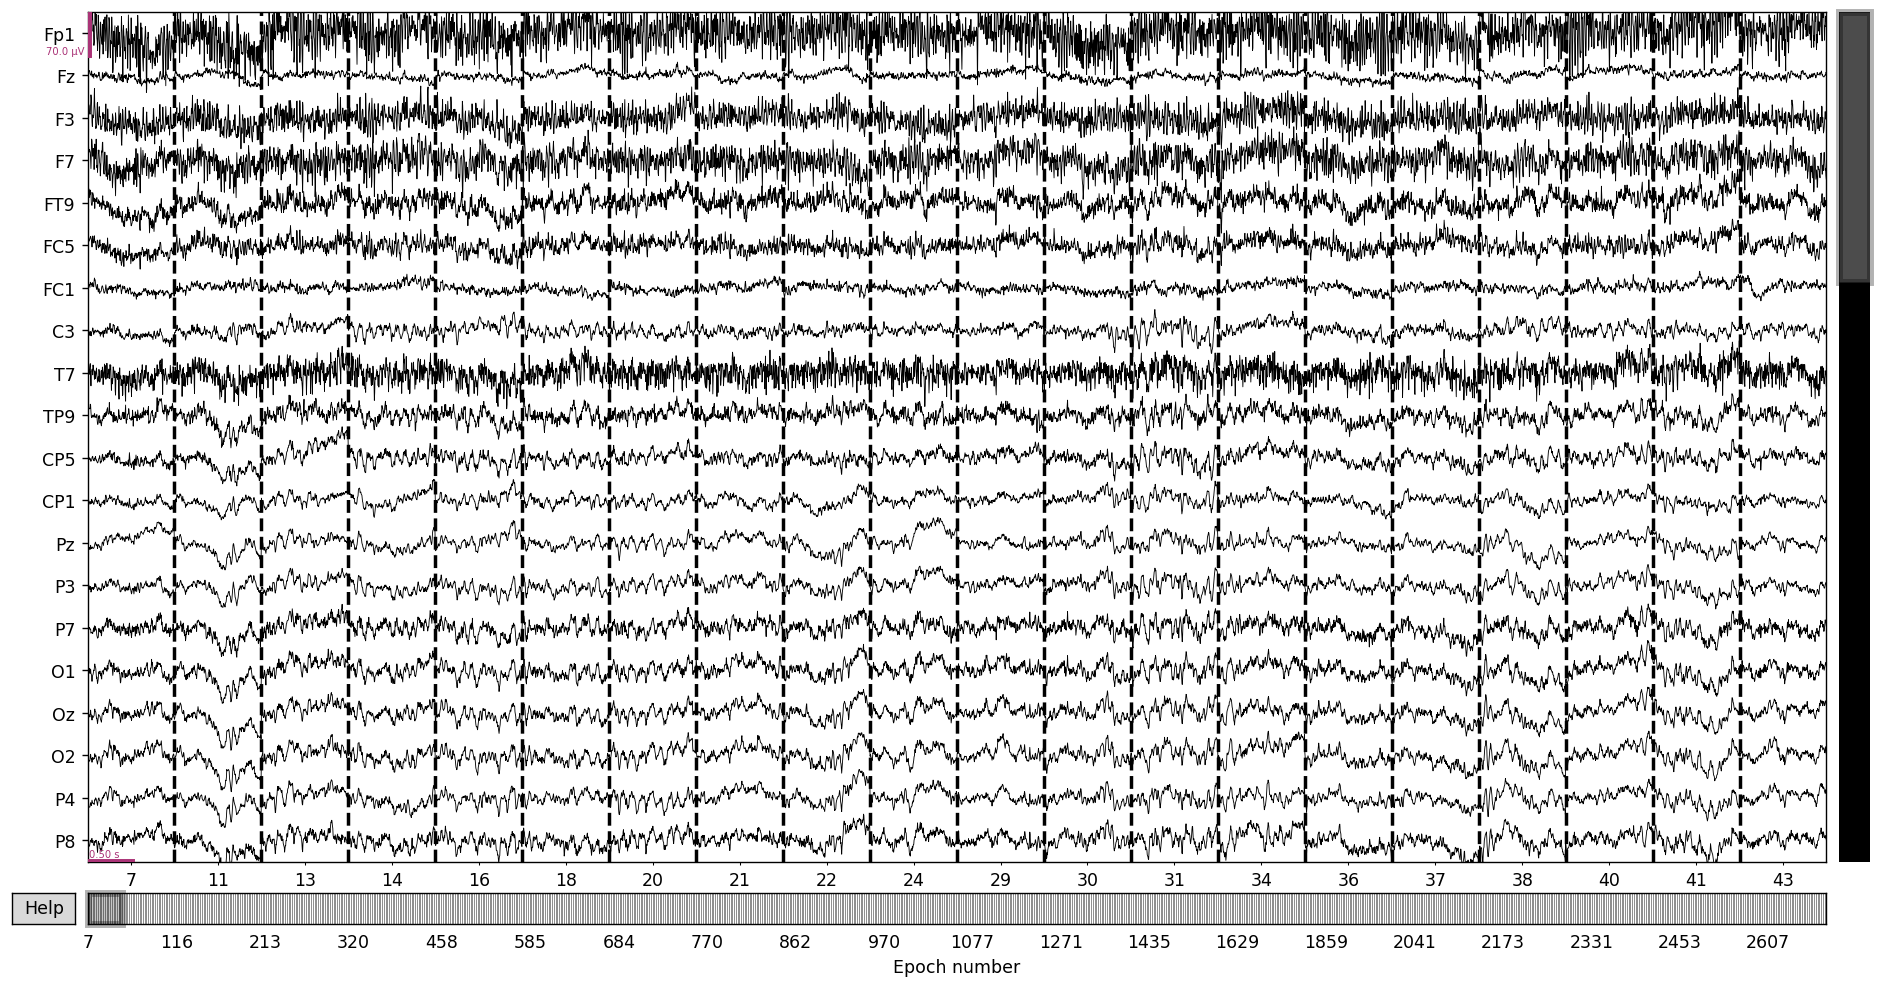

Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [26]:
epochs.plot(scalings=dict(eeg=35e-6))

In [27]:

baseline_tmin, baseline_tmax = -.3, 0  # None takes the first timepoint

baseline = (baseline_tmin, baseline_tmax)
B1_devi_eps = epochs['15'].average().apply_baseline(baseline)
B1_sta_eps =  epochs["14"].average().apply_baseline(baseline)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


In [28]:
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=B1_devi_eps, standard=B1_sta_eps)
picks = [1,34,35,3,37,36]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


[<Figure size 1000x750 with 1 Axes>]

In [29]:
MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=B1_devi_eps, standard=B1_sta_eps,MMN = MMN_erp)
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


[<Figure size 1000x750 with 1 Axes>]

### Iterate in different subject data 


In [3]:
import os
import mne
data_folder = r"D:\Data_at_IITJ/"
subjects = os.listdir(data_folder)
data_type = "EEG"


In [17]:
num_epoch= {"subject":[],
             "B1_standard":[],
             "B1_deviant":[],
             "B2_standard":[],
             "B2_deviant":[],
             "B1_standard_AR":[],
             "B1_deviant_AR":[],
             "B2_standard_AR":[],
             "B2_deviant_AR":[],
             }

for sub in subjects:
    path = os.path.join(data_folder,sub,data_type)
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
            print(eeg)
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=False)
            raw.plot(scalings=dict(eeg=1e-4),clipping='transparent')
            raw.set_montage("easycap-M1")
            raw.resample(sfreq=250)
            raw.compute_psd().plot(picks="data", amplitude=False)
            raw.notch_filter(50)
            raw.filter(l_freq=0.1,h_freq=100)
            raw.compute_psd().plot(picks="data", amplitude=False)
            #Get the events and its marker
            try : 
                events,event_dict = mne.events_from_annotations(raw)
                epochs = mne.Epochs(raw, events, event_id=[14,15,24,25], tmin=-0.3, tmax=0.7, preload=True)
                
                num_epoch['subject'].append(sub)
                num_epoch["B1_standard"].append(len(epochs['14']))
                num_epoch["B1_deviant"].append(len(epochs['15']))
                num_epoch["B2_standard"].append(len(epochs['24']))
                num_epoch["B2_deviant"].append(len(epochs['25']))
                print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
                print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))
                # Define the rejection criteria
                reject_criteria = dict(eeg=70e-6)  # 70 microvolts
                bad_epochs = []
                for i, epoch in enumerate(epochs):
                    # Find channels that exceed the threshold
                    #print((abs(epoch) > reject_criteria['eeg']).any(axis=1).sum())
                    bad_channels = (abs(epoch) > reject_criteria['eeg']).any(axis=1) 
                    # Check if more than 3 electrodes exceed the threshold
                    if bad_channels.sum() > 5:
                        bad_epochs.append(i)
                    
                # Drop the bad epochs
                epochs.drop(bad_epochs)
                print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
                print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))
                
                num_epoch["B1_standard_AR"].append(len(epochs['14']))
                num_epoch["B1_deviant_AR"].append(len(epochs['15']))
                num_epoch["B2_standard_AR"].append(len(epochs['24']))
                num_epoch["B2_deviant_AR"].append(len(epochs['25']))
            except:
                pass
                
    print(os.path.join(data_folder,sub,data_type))

sub002_saurabh_NET.vhdr
Extracting parameters from D:\Data_at_IITJ/sub002\EEG\sub002_saurabh_NET.vhdr...
Setting channel info structure...


c:\Users\CSNDLab\.conda\envs\EEG_analysis\Lib\site-packages\mne\viz\utils.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 8251 samples (33.004 s)



...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Used Annotations descriptions: ['New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
Not setting metadata
1852 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1852 events and 251 original time points ...
0 bad epochs dropped
Total Numner of event in Block 1 : 795 157
Total Numner of event in Block 2 : 750 150
Dropped 94 epochs: 11, 20, 21, 27, 28, 29, 33, 44, 45, 46, 47, 48, 49, 243, 256, 533, 534, 566, 567, 568, 569, 726, 743, 744, 745, 746, 747, 748, 803, 805, 806, 808, 812, 813, 814, 815, 816, 913, 943, 1009, 1195, 1197, 1198, 1244, 1254, 1293, 1295, 1299, 1336, 1340, 1343, 1348, 1357, 1371, 1374, 1375, 1384, 1388, 1402, 1403, 1406, 1408, 1409, 1410, 1412, 1418, 1419, 1423, 1425, 1433, 1435

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


In [19]:
import pandas  as pd
data_epoch=pd.DataFrame(num_epoch)
data_epoch

,subject,B1_standard,B1_deviant,B2_standard,B2_deviant,B1_standard_AR,B1_deviant_AR,B2_standard_AR,B2_deviant_AR
0,sub002,582,117,150,750,207,37,61,284
1,sub004,750,150,750,150,63,4,79,15
2,sub005,750,150,750,150,559,106,587,120
3,sub006,750,150,750,150,344,63,201,47
4,sub007,750,150,750,150,411,90,432,70
5,sub008,750,150,750,150,627,121,614,121
6,sub009,750,150,750,150,631,130,609,125
7,sub010,795,157,750,150,766,147,702,143
